In [235]:
from sklearn.preprocessing import MinMaxScaler

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

In [196]:
train_raw = pd.read_csv('rossmann-store-sales/train.csv')
store_raw = pd.read_csv('rossmann-store-sales/store.csv')
test_raw = pd.read_csv('rossmann-store-sales/test.csv')

C:\Users\isaac.barros_santodi\AppData\Local\Temp\ipykernel_23880\776880573.py:1: DtypeWarning: Columns (7) have mixed types. Specify dtype option on import or set low_memory=False.
  train_raw = pd.read_csv('rossmann-store-sales/train.csv')


In [197]:
train_raw

,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday
0,1,5,2015-07-31,5263,555,1,1,0,1
1,2,5,2015-07-31,6064,625,1,1,0,1
2,3,5,2015-07-31,8314,821,1,1,0,1
3,4,5,2015-07-31,13995,1498,1,1,0,1
4,5,5,2015-07-31,4822,559,1,1,0,1
...,...,...,...,...,...,...,...,...,...
1017204,1111,2,2013-01-01,0,0,0,0,a,1
1017205,1112,2,2013-01-01,0,0,0,0,a,1
1017206,1113,2,2013-01-01,0,0,0,0,a,1
1017207,1114,2,2013-01-01,0,0,0,0,a,1


In [198]:
store_raw

,Store,StoreType,Assortment,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear,PromoInterval
0,1,c,a,1270.0,9.0,2008.0,0,NaN,NaN,NaN
1,2,a,a,570.0,11.0,2007.0,1,13.0,2010.0,"Jan,Apr,Jul,Oct"
2,3,a,a,14130.0,12.0,2006.0,1,14.0,2011.0,"Jan,Apr,Jul,Oct"
3,4,c,c,620.0,9.0,2009.0,0,NaN,NaN,NaN
4,5,a,a,29910.0,4.0,2015.0,0,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...
1110,1111,a,a,1900.0,6.0,2014.0,1,31.0,2013.0,"Jan,Apr,Jul,Oct"
1111,1112,c,c,1880.0,4.0,2006.0,0,NaN,NaN,NaN
1112,1113,a,c,9260.0,NaN,NaN,0,NaN,NaN,NaN
1113,1114,a,c,870.0,NaN,NaN,0,NaN,NaN,NaN


In [199]:
train_raw.dtypes

Store             int64
DayOfWeek         int64
Date             object
Sales             int64
Customers         int64
Open              int64
Promo             int64
StateHoliday     object
SchoolHoliday     int64
dtype: object

In [200]:
train = train_raw.copy()

In [201]:
# Buscando por valores nulos ou quebrados

print(train_raw.isnull().sum())
print("----------\n",store_raw.isnull().sum())

Store            0
DayOfWeek        0
Date             0
Sales            0
Customers        0
Open             0
Promo            0
StateHoliday     0
SchoolHoliday    0
dtype: int64
----------
 Store                          0
StoreType                      0
Assortment                     0
CompetitionDistance            3
CompetitionOpenSinceMonth    354
CompetitionOpenSinceYear     354
Promo2                         0
Promo2SinceWeek              544
Promo2SinceYear              544
PromoInterval                544
dtype: int64


In [202]:
train['Store'].unique()

array([   1,    2,    3, ..., 1113, 1114, 1115], shape=(1115,))

In [203]:
# Criando agrupamento para visualização do gráfico de comportamento das vendas e consumidores

store_sales = train.groupby(['Store','Date'])['Sales'].sum().reset_index()

store_sales_pivot = pd.pivot_table(store_sales, values='Sales', index='Date', columns='Store', aggfunc='sum')

store_sales_pivot.head()

Store,1,2,3,4,5,6,7,8,9,10,...,1106,1107,1108,1109,1110,1111,1112,1113,1114,1115
Date,,,,,,,,,,,,,,,,,,,,,
2013-01-01,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2013-01-02,5530.0,4422.0,6823.0,9941.0,4253.0,6089.0,8244.0,5419.0,4903.0,4812.0,...,5099.0,3955.0,6220.0,4576.0,4126.0,5097.0,10797.0,6218.0,20642.0,3697.0
2013-01-03,4327.0,4159.0,5902.0,8247.0,3465.0,5398.0,7231.0,4842.0,4602.0,4675.0,...,4330.0,3151.0,4779.0,3654.0,3508.0,4579.0,8716.0,5563.0,18463.0,4297.0
2013-01-04,4486.0,4484.0,6069.0,8290.0,4456.0,6092.0,7758.0,4059.0,4798.0,5114.0,...,3956.0,3990.0,5491.0,3596.0,3933.0,4640.0,9788.0,5524.0,18371.0,4540.0
2013-01-05,4997.0,2342.0,4523.0,10338.0,1590.0,3872.0,5218.0,2337.0,4254.0,4256.0,...,2624.0,5128.0,2113.0,2897.0,3156.0,3325.0,9513.0,5194.0,18856.0,4771.0


([0,
  1,
  2,
  3,
  4,
  5,
  6,
  7,
  8,
  9,
  10,
  11,
  12,
  13,
  14,
  15,
  16,
  17,
  18,
  19,
  20,
  21,
  22,
  23,
  24,
  25,
  26,
  27,
  28,
  29,
  30,
  31,
  32,
  33,
  34,
  35,
  36,
  37,
  38,
  39,
  40,
  41,
  42,
  43,
  44,
  45,
  46,
  47,
  48,
  49],
 [Text(0, 0, '2013-01-01'),
  Text(1, 0, '2013-01-02'),
  Text(2, 0, '2013-01-03'),
  Text(3, 0, '2013-01-04'),
  Text(4, 0, '2013-01-05'),
  Text(5, 0, '2013-01-06'),
  Text(6, 0, '2013-01-07'),
  Text(7, 0, '2013-01-08'),
  Text(8, 0, '2013-01-09'),
  Text(9, 0, '2013-01-10'),
  Text(10, 0, '2013-01-11'),
  Text(11, 0, '2013-01-12'),
  Text(12, 0, '2013-01-13'),
  Text(13, 0, '2013-01-14'),
  Text(14, 0, '2013-01-15'),
  Text(15, 0, '2013-01-16'),
  Text(16, 0, '2013-01-17'),
  Text(17, 0, '2013-01-18'),
  Text(18, 0, '2013-01-19'),
  Text(19, 0, '2013-01-20'),
  Text(20, 0, '2013-01-21'),
  Text(21, 0, '2013-01-22'),
  Text(22, 0, '2013-01-23'),
  Text(23, 0, '2013-01-24'),
  Text(24, 0, '2013-01-

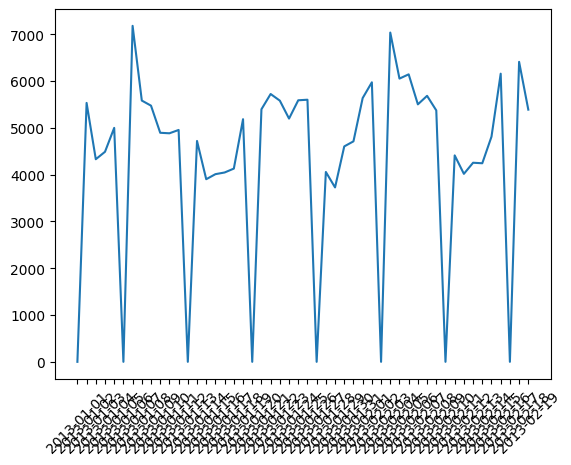

In [204]:
plt.plot(store_sales_pivot.index[0:50], store_sales_pivot[1][0:50])
plt.xticks(rotation=45) 

In [205]:
# Todas as lojas fecham no mesmo dia (exceto feriados)?
print("Count dias fechados por dia da semana:\n",train[(train['Open'] == 0) & (train['StateHoliday'] == 0)]['DayOfWeek'].value_counts())

train[(train['DayOfWeek'] == 7) & (train['Sales'] > 0)]

# R: Não. Esta variável deve ser incluída para personalizar a expectativa de cada loja

Count dias fechados por dia da semana:
 DayOfWeek
7    18567
1       90
2       62
4       56
6       53
5       53
3       51
Name: count, dtype: int64


,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday
5659,85,7,2015-07-26,11421,1606,1,0,0,0
5696,122,7,2015-07-26,5773,707,1,0,0,0
5783,209,7,2015-07-26,3742,354,1,0,0,0
5833,259,7,2015-07-26,15998,2857,1,0,0,0
5836,262,7,2015-07-26,32547,4783,1,0,0,0
...,...,...,...,...,...,...,...,...,...
1011252,733,7,2013-01-06,11226,2584,1,0,0,0
1011288,769,7,2013-01-06,6995,1764,1,0,0,0
1011382,863,7,2013-01-06,2067,255,1,0,0,0
1011467,948,7,2013-01-06,6024,1402,1,0,a,0


## Feature Engineering

- Feature engineering

Flag de feriado

Dia da semana

Mês do ano

Open (?)

Promo

SchoolHoliday

In [206]:
train.head()

,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday
0,1,5,2015-07-31,5263,555,1,1,0,1
1,2,5,2015-07-31,6064,625,1,1,0,1
2,3,5,2015-07-31,8314,821,1,1,0,1
3,4,5,2015-07-31,13995,1498,1,1,0,1
4,5,5,2015-07-31,4822,559,1,1,0,1


In [ ]:
# Features de Data

train['Month'] = train['Date'].apply(lambda x: x.split('-')[1]).astype(int)

train['StateHoliday'] = train['StateHoliday'].apply(lambda x: 1 if x != '0' else 0).astype(int) 

train.head()

,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday,Month,Trimester
0,1,5,2015-07-31,5263,555,1,1,0,1,7,3
1,2,5,2015-07-31,6064,625,1,1,0,1,7,3
2,3,5,2015-07-31,8314,821,1,1,0,1,7,3
3,4,5,2015-07-31,13995,1498,1,1,0,1,7,3
4,5,5,2015-07-31,4822,559,1,1,0,1,7,3


In [208]:
# Feature de Média Móvel

train['7_days_avg_sales'] = train.groupby(['Store'])['Sales'].transform(lambda x: x.rolling(7, min_periods=1).mean())

In [209]:
train.head()

,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday,Month,Trimester,7_days_avg_sales
0,1,5,2015-07-31,5263,555,1,1,0,1,7,3,5263.0
1,2,5,2015-07-31,6064,625,1,1,0,1,7,3,6064.0
2,3,5,2015-07-31,8314,821,1,1,0,1,7,3,8314.0
3,4,5,2015-07-31,13995,1498,1,1,0,1,7,3,13995.0
4,5,5,2015-07-31,4822,559,1,1,0,1,7,3,4822.0


### Join Table - store.csv

In [210]:
store_raw.head()

,Store,StoreType,Assortment,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear,PromoInterval
0,1,c,a,1270.0,9.0,2008.0,0,NaN,NaN,NaN
1,2,a,a,570.0,11.0,2007.0,1,13.0,2010.0,"Jan,Apr,Jul,Oct"
2,3,a,a,14130.0,12.0,2006.0,1,14.0,2011.0,"Jan,Apr,Jul,Oct"
3,4,c,c,620.0,9.0,2009.0,0,NaN,NaN,NaN
4,5,a,a,29910.0,4.0,2015.0,0,NaN,NaN,NaN


In [211]:
df_join = pd.merge(train, store_raw, on ='Store', how ='left')

In [212]:
df_join.head(5)

,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday,Month,...,7_days_avg_sales,StoreType,Assortment,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear,PromoInterval
0,1,5,2015-07-31,5263,555,1,1,0,1,7,...,5263.0,c,a,1270.0,9.0,2008.0,0,NaN,NaN,NaN
1,2,5,2015-07-31,6064,625,1,1,0,1,7,...,6064.0,a,a,570.0,11.0,2007.0,1,13.0,2010.0,"Jan,Apr,Jul,Oct"
2,3,5,2015-07-31,8314,821,1,1,0,1,7,...,8314.0,a,a,14130.0,12.0,2006.0,1,14.0,2011.0,"Jan,Apr,Jul,Oct"
3,4,5,2015-07-31,13995,1498,1,1,0,1,7,...,13995.0,c,c,620.0,9.0,2009.0,0,NaN,NaN,NaN
4,5,5,2015-07-31,4822,559,1,1,0,1,7,...,4822.0,a,a,29910.0,4.0,2015.0,0,NaN,NaN,NaN


In [223]:
# Dummie values para a categoria da loja
df_encoded = pd.get_dummies(df_join, columns=['StoreType'])

# Flag de distancia para competidores
df_encoded['CompetitionDistance_less_1000'] = df_encoded['CompetitionDistance'].apply(lambda x: 1 if x < 1000 else 0)


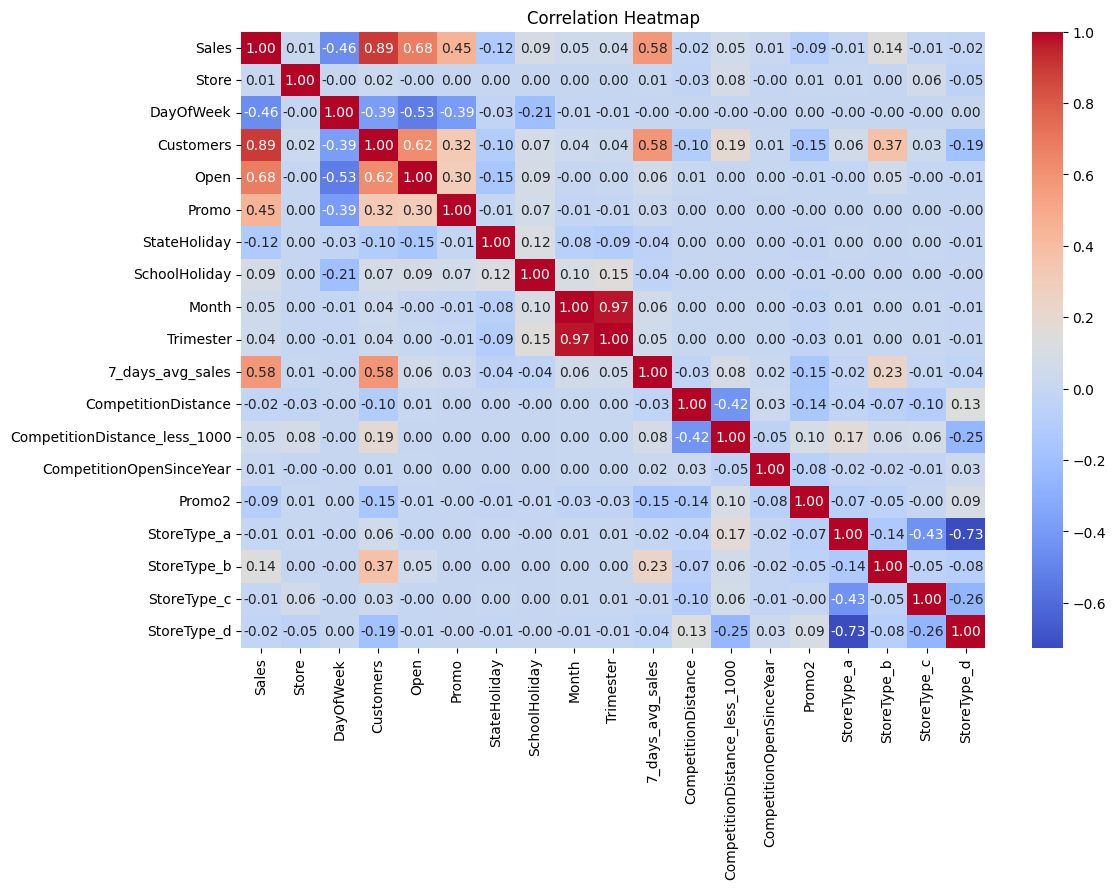

In [224]:
columns = ['Sales', 'Store', 'DayOfWeek', 'Customers', 'Open', 'Promo',
       'StateHoliday', 'SchoolHoliday', 'Month', 'Trimester',
       '7_days_avg_sales', 'CompetitionDistance', 'CompetitionDistance_less_1000', 'CompetitionOpenSinceYear', 'Promo2', 
        'StoreType_a', 'StoreType_b',
       'StoreType_c', 'StoreType_d']

plt.figure(figsize=(12,8))
sns.heatmap(df_encoded[columns].corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap')
plt.show()

Manter:

DayOfWeek

Customers

Open

Promo

7_days_avg_sales



## Model Training

### Preparação dos Dados para o modelo LSTM

In [230]:
df = df_encoded[['Store','Date','DayOfWeek','Customers','Open','Promo','7_days_avg_sales','Sales']]

df.head()

,Store,Date,DayOfWeek,Customers,Open,Promo,7_days_avg_sales,Sales
0,1,2015-07-31,5,555,1,1,5263.0,5263
1,2,2015-07-31,5,625,1,1,6064.0,6064
2,3,2015-07-31,5,821,1,1,8314.0,8314
3,4,2015-07-31,5,1498,1,1,13995.0,13995
4,5,2015-07-31,5,559,1,1,4822.0,4822


In [232]:
df = df.sort_values(['Store', 'Date'])
df.head()

,Store,Date,DayOfWeek,Customers,Open,Promo,7_days_avg_sales,Sales
1016095,1,2013-01-01,2,0,0,0,3788.000000,0
1014980,1,2013-01-02,3,668,1,0,4585.142857,5530
1013865,1,2013-01-03,4,578,1,0,4576.714286,4327
1012750,1,2013-01-04,5,619,1,0,4657.428571,4486
1011635,1,2013-01-05,6,635,1,0,4713.857143,4997


In [ ]:
scaler = MinMaxScaler()
num_features = ['DayOfWeek','Customers', 'Open', 'Promo', '7_days_avg_sales', 'Sales']

df[num_features] = scaler.fit_transform(df[num_features])

In [236]:
# Criando sequencias de entrada do modelo para cada Store ID
def create_sequences(df, store_id, seq_length=7):
    store_data = df[df['Store'] == store_id]
    features = ['Customers', 'Open', 'Promo', '7_days_avg_sales','DayOfWeek']
    target = 'Sales'

    X, y = [], []
    for i in range(seq_length, len(store_data)):
        X.append(store_data[features].iloc[i-seq_length:i].values)
        y.append(store_data[target].iloc[i])

    return np.array(X), np.array(y)

# Exemplo para a loja 1
X_store1, y_store1 = create_sequences(df, store_id=1, seq_length=7)
print(X_store1.shape)  # (n_samples, 7, n_features)
print(y_store1.shape)  # (n_samples,)


(935, 7, 5)
(935,)


In [237]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense

n_features = X_store1.shape[2]

model = Sequential()
model.add(LSTM(50, activation='relu', input_shape=(7, n_features)))
model.add(Dense(1))  # previsão de 1 valor: Sales

model.compile(optimizer='adam', loss='mse')
model.summary()


C:\Users\isaac.barros_santodi\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\keras\src\layers\rnn\rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 50)             │        11,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,251 (43.95 KB)

 Trainable params: 11,251 (43.95 KB)

 Non-trainable params: 0 (0.00 B)